# 1D Pyrite Oxidation with BYO(Build your own model files)

This tutorial reproduces the marine-sediment oxidation experiment of
Appelo et al. (1998): a column of pyrite-bearing sediment is first flushed
with a dilute MgCl\ :sub:`2` solution and then with an oxidising solution,
driving pyrite oxidation and a cascade of secondary reactions (calcite
dissolution, cation/proton exchange, organic-matter oxidation, surface
complexation).

It uses the **classic workflow (BYO)**: build the :class:`~mf6rtm.mup3d.base.Mup3d`
model first, then construct the MODFLOW 6 flow + per-component transport models
yourself. The classic workflow injects the inflow chemistry directly into the
well as per-period auxiliary concentrations, so the injected water can change
between stress periods (dilute in period 0, oxidising in period 1).

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import flopy

from mf6rtm import utils, mup3d

BASE = "." if os.path.isdir("data") else os.path.join("docs", "tutorials")
DATA = os.path.join(BASE, "data")

## 1. Discretization and flow

A 5.3 cm column in 16 cells, run in two stress periods: a dilute flush
(period 0) followed by the oxidising flush (period 1). The injection well at
the inlet runs at the same rate in both periods; only its chemistry changes.

In [2]:
length_units = "meters"
time_units = "days"

nlay, nrow, ncol = 1, 1, 16
Lx = 0.053
delr = Lx / ncol
delc = 1.0
top = 2.87433e-03
botm = np.linspace(top, 0.0, nlay + 1)[1:]

k11 = 1.0
prsity = 0.376
dispersivity = 0.00537

q = 2.4e-4  # injection rate (m3/d)

nper = 2
nstp = [64, 100]
perlen = [0.9333, 1.45833]
tdis_rc = [(pl, ns, 1.0) for pl, ns in zip(perlen, nstp)]

# constant head at the outlet; injection well at the inlet in both periods
chdspd = [[(0, 0, ncol - 1), 1.0]]
wel_spd = {kper: [[(0, 0, 0), q]] for kper in range(nper)}

## 2. Geochemistry — defining the reaction network

mf6rtm mirrors PHREEQC's chemistry blocks as ``mup3d`` classes. Every input
type follows the same pattern: **load** the data (here from CSV via a
``utils`` helper), **wrap** it in the matching class, and **place** it with
``.set_ic(...)`` — an integer *zone number* for uniform chemistry, or a
``(nlay, nrow, ncol)`` array of zone numbers for spatially varying chemistry.
The objects are attached to the ``Mup3d`` model in the next section.

**Solutions** — the aqueous waters (pH, pe, element totals), one per column.
Column ``1`` is the initial pore water (applied everywhere); columns ``2`` and
``3`` are the dilute and oxidising inflow waters injected in periods 0 and 1.

In [3]:
solutionsdf = pd.read_csv(os.path.join(DATA, "tut02_solutions.csv"),
                          comment="#", index_col=0)
solutions = utils.solution_df_to_dict(solutionsdf)
solution = mup3d.Solutions(solutions)
solution.set_ic(np.ones((nlay, nrow, ncol), dtype=float))
solutionsdf

,cinit,cin_1,cin_2
comp,,,
Ca,0.000386,1.000000e-06,1.000000e-07
Cl,0.020070,5.301000e-03,1.020000e-02
Mg,0.010000,2.650000e-03,5.100000e-03
Fe(+2),0.000001,1.000000e-08,2.000000e-07
Fe(+3),0.000000,0.000000e+00,0.000000e+00
S(6),0.000010,1.000000e-08,2.000000e-07
S(-2),0.000000,0.000000e+00,0.000000e+00
C(+4),0.000586,1.000000e-06,1.000000e-07
C(-4),0.000000,0.000000e+00,0.000000e+00


**Exchange phases** — cation-exchange sites (PHREEQC ``EXCHANGE``). The column
is split into four zones with different exchanger amounts; the ``set_ic`` array
maps cells 0–3 → zone 1, 4–7 → zone 2, and so on.
``set_equilibrate_solutions`` pre-equilibrates each zone's exchanger with the
given solution number before the run.

In [4]:
excdf = pd.read_csv(os.path.join(DATA, "tut02_exchange.csv"), comment="#", index_col=0)
excdf.columns = [0, 1, 2, 3]
exchanger_dict = excdf.to_dict()
for _z, subdict in exchanger_dict.items():
    for key in subdict:
        subdict[key] = {"m0": subdict[key]}
exchanger = mup3d.ExchangePhases(exchanger_dict)

exchanger_ic = np.ones((nlay, nrow, ncol), dtype=float)
exchanger_ic[0, 0, :4] = 1
exchanger_ic[0, 0, 4:8] = 2
exchanger_ic[0, 0, 8:12] = 3
exchanger_ic[0, 0, 12:] = 4
exchanger.set_ic(exchanger_ic)
exchanger.set_equilibrate_solutions([1, 1, 1, 1])

**Kinetic phases** — rate-controlled reactions (PHREEQC ``KINETICS``): pyrite
and organic-matter oxidation, the drivers of this experiment.
``parse_kinetics_dataframe`` builds the per-phase parameter dict; ``set_ic(1)``
applies the same kinetics to every cell.

In [5]:
kin_df = pd.read_csv(os.path.join(DATA, "tut02_kinetic_phases.csv"))
kin_phases = utils.parse_kinetics_dataframe(kin_df)
kin_phases[1]["Orgc_sed"]["formula"] = "Orgc_sed -1.0 C 1.0"
kinetics = mup3d.KineticPhases(kin_phases)
kinetics.set_ic(1)

**Equilibrium phases & surfaces** — ``EquilibriumPhases`` are minerals kept at
equilibrium each step (PHREEQC ``EQUILIBRIUM_PHASES``, here calcite);
``Surfaces`` are surface-complexation sites (PHREEQC ``SURFACE``). Both are
uniform, so ``set_ic(1)``.

In [6]:
eqp_df = pd.read_csv(os.path.join(DATA, "tut02_equilibrium_phases.csv"))
equilibriums = mup3d.EquilibriumPhases(utils.parse_equilibriums_dataframe(eqp_df))
equilibriums.set_ic(1)

surfaces = mup3d.Surfaces(utils.surfaces_csv_to_dict(
    os.path.join(DATA, "tut02_surfaces.csv")))
surfaces.set_ic(1)

## 3. Build the `Mup3d` model and assign inflow chemistry

Create the model, attach every phase type, and initialize PhreeqcRM. Then map
the inflow solutions to the well **per stress period** with ``set_spd([2, 3])``
(solution 2 in period 0, solution 3 in period 1). ``set_chem_stress`` stores
the per-period component concentrations in ``model.wel.data``.

In [7]:
sim_ws = os.path.join(BASE, "_tutorial02_run")
model = mup3d.Mup3d("pyrite_oxidation", solution, nlay, nrow, ncol)
model.set_wd(sim_ws)
model.set_database(os.path.join(DATA, "tut02_datab.dat"))
model.set_initial_temp([7.0, 7.0, 7.0])
model.set_postfix(os.path.join(DATA, "tut02_postfix.phqr"))

model.set_exchange_phases(exchanger)
model.set_phases(kinetics)
model.set_phases(equilibriums)
model.set_phases(surfaces)

model.initialize()

# inflow chemistry: solution 2 (dilute) in period 0, solution 3 (oxidising) in period 1
wellchem = mup3d.ChemStress("wel")
wellchem.set_spd([2, 3])
model.set_chem_stress(wellchem)

# append the per-period component concentrations to the well stress period data
for kper in wel_spd:
    for i in range(len(wel_spd[kper])):
        wel_spd[kper][i].extend(model.wel.data[kper])

Using temperatue of 7.0 from SOLUTION 1 for all cells
MF6RTM will run with the following configuration:
  Reactive: True
  Reaction timing: all
  External files flag: False
  Emulator flag: False
  Min concentration: None (no clipping)
  Reactions calculated at all time steps
Phreeqc initialized
Initializing ChemStress
ChemStress wel initialized


## 4. Build the flow + per-component transport models

The well injects the components as auxiliary variables (per period); one GWT
model is then built per chemical component, each sourcing the well auxiliary.

In [8]:
def build_model(model):
    sim = flopy.mf6.MFSimulation(sim_name=model.name, sim_ws=model.wd, exe_name="mf6")
    flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=tdis_rc, time_units=time_units)

    # --- GWF flow model ---
    gwf = flopy.mf6.ModflowGwf(sim, modelname="gwf", save_flows=True)
    imsgwf = flopy.mf6.ModflowIms(sim, complexity="complex", linear_acceleration="CG",
                                  filename="gwf.ims")
    sim.register_ims_package(imsgwf, [gwf.name])

    flopy.mf6.ModflowGwfdis(gwf, length_units=length_units, nlay=nlay, nrow=nrow,
                            ncol=ncol, delr=delr, delc=delc, top=top, botm=botm,
                            filename="gwf.dis")
    flopy.mf6.ModflowGwfnpf(gwf, save_specific_discharge=True, save_saturation=True,
                            icelltype=1, k=k11, filename="gwf.npf")
    flopy.mf6.ModflowGwfic(gwf, strt=1.0, filename="gwf.ic")
    flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chdspd, pname="chd",
                            filename="gwf.chd")
    flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_spd, auxiliary=model.components,
                            pname="wel", filename="gwf.wel")
    flopy.mf6.ModflowGwfoc(gwf, head_filerecord="gwf.hds", budget_filerecord="gwf.cbb",
                           saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])

    # --- one GWT model per component ---
    for c in model.components:
        gwt = flopy.mf6.MFModel(sim, model_type="gwt6", modelname=c,
                                model_nam_file=f"{c}.nam")
        imsgwt = flopy.mf6.ModflowIms(sim, linear_acceleration="BICGSTAB",
                                      filename=f"{c}.ims")
        sim.register_ims_package(imsgwt, [gwt.name])

        flopy.mf6.ModflowGwtdis(gwt, length_units=length_units, nlay=nlay, nrow=nrow,
                                ncol=ncol, delr=delr, delc=delc, top=top, botm=botm,
                                filename=f"{c}.dis")
        flopy.mf6.ModflowGwtic(gwt, strt=model.sconc[c], filename=f"{c}.ic")
        flopy.mf6.ModflowGwtssm(gwt, sources=[["wel", "aux", c]], filename=f"{c}.ssm")
        flopy.mf6.ModflowGwtadv(gwt, scheme="tvd")
        flopy.mf6.ModflowGwtdsp(gwt, xt3d_off=True, alh=dispersivity,
                                ath1=dispersivity * 0.1, filename=f"{c}.dsp")
        flopy.mf6.ModflowGwtmst(gwt, porosity=prsity, filename=f"{c}.mst")
        flopy.mf6.ModflowGwtoc(gwt, concentration_filerecord=f"{c}.ucn",
                               saverecord=[("CONCENTRATION", "ALL")])
        flopy.mf6.ModflowGwfgwt(sim, exgtype="GWF6-GWT6", exgmnamea="gwf",
                                exgmnameb=c, filename=f"{c}.gwfgwt")

    sim.write_simulation()
    return sim


sim = build_model(model)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_0...
  writing solution package ims_1...
  writing solution package ims_2...
  writing solution package ims_3...
  writing solution package ims_4...
  writing solution package ims_5...
  writing solution package ims_6...
  writing solution package ims_7...
  writing solution package ims_8...
  writing solution package ims_9...
  writing package H.gwfgwt...
  writing package O.gwfgwt...
  writing package Charge.gwfgwt...
  writing package C.gwfgwt...
  writing package Ca.gwfgwt...
  writing package Cl.gwfgwt...
  writing package Fe.gwfgwt...
  writing package Mg.gwfgwt...
  writing package Orgc_sed.gwfgwt...
  writing package S.gwfgwt...
  writing model gwf...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package chd...
INFORMATION: maxbound in ('gwf6',

## 5. Run

In [9]:
# Stage the platform's MODFLOW 6 binaries into the run directory (pixi fetches
# them into ``benchmark/bin``) so the solver finds libmf6 locally.
utils.prep_bins(model.wd, src_path=os.path.join(BASE, "..", "..", "benchmark", "bin"))

model.run()

Running mf6rtm


Using libmf6 found in model directory: libmf6.dylib


Processing initial chemistry configuration
Starting Solution at 2026-07-20 15:57:02
Transport       | Stress period:  1     | Time step:      1          | Completed in :  0 min   1.03e-06 sec
Reactions       | Stress period:  1     | Time step:      1          | Completed in :  0 min   1.11e-04 sec
Transport       | Stress period:  1     | Time step:      2          | Completed in :  0 min   1.00e-06 sec
Reactions       | Stress period:  1     | Time step:      2          | Completed in :  0 min   8.82e-04 sec
Transport       | Stress period:  1     | Time step:      3          | Completed in :  0 min   1.58e-06 sec
Reactions       | Stress period:  1     | Time step:      3          | Completed in :  0 min   7.54e-04 sec
Transport       | Stress period:  1     | Time step:      4          | Completed in :  0 min   1.37e-06 sec
Reactions       | Stress period:  1     | Time step:      4          | Completed in :  0 min   5.70e-04 sec
Transport       | Stress period:  1     | Time step:

Transport       | Stress period:  1     | Time step:      6          | Completed in :  0 min   1.22e-06 sec
Reactions       | Stress period:  1     | Time step:      6          | Completed in :  0 min   5.60e-04 sec
Transport       | Stress period:  1     | Time step:      7          | Completed in :  0 min   1.23e-06 sec
Reactions       | Stress period:  1     | Time step:      7          | Completed in :  0 min   5.43e-04 sec
Transport       | Stress period:  1     | Time step:      8          | Completed in :  0 min   1.50e-06 sec
Reactions       | Stress period:  1     | Time step:      8          | Completed in :  0 min   5.37e-04 sec
Transport       | Stress period:  1     | Time step:      9          | Completed in :  0 min   1.40e-06 sec
Reactions       | Stress period:  1     | Time step:      9          | Completed in :  0 min   5.48e-04 sec
Transport       | Stress period:  1     | Time step:      10         | Completed in :  0 min   1.42e-06 sec
Reactions       | Stress per

Reactions       | Stress period:  1     | Time step:      11         | Completed in :  0 min   5.14e-04 sec
Transport       | Stress period:  1     | Time step:      12         | Completed in :  0 min   1.30e-06 sec
Reactions       | Stress period:  1     | Time step:      12         | Completed in :  0 min   4.83e-04 sec
Transport       | Stress period:  1     | Time step:      13         | Completed in :  0 min   1.75e-06 sec
Reactions       | Stress period:  1     | Time step:      13         | Completed in :  0 min   4.58e-04 sec
Transport       | Stress period:  1     | Time step:      14         | Completed in :  0 min   1.45e-06 sec
Reactions       | Stress period:  1     | Time step:      14         | Completed in :  0 min   4.35e-04 sec
Transport       | Stress period:  1     | Time step:      15         | Completed in :  0 min   1.20e-06 sec
Reactions       | Stress period:  1     | Time step:      15         | Completed in :  0 min   4.10e-04 sec
Transport       | Stress per

...

Reactions       | Stress period:  2     | Time step:      86         | Completed in :  0 min   6.69e-04 sec
Transport       | Stress period:  2     | Time step:      87         | Completed in :  0 min   6.50e-07 sec
Reactions       | Stress period:  2     | Time step:      87         | Completed in :  0 min   7.13e-04 sec
Transport       | Stress period:  2     | Time step:      88         | Completed in :  0 min   6.00e-07 sec
Reactions       | Stress period:  2     | Time step:      88         | Completed in :  0 min   6.56e-04 sec
Transport       | Stress period:  2     | Time step:      89         | Completed in :  0 min   6.83e-07 sec
Reactions       | Stress period:  2     | Time step:      89         | Completed in :  0 min   6.61e-04 sec
Transport       | Stress period:  2     | Time step:      90         | Completed in :  0 min   6.50e-07 sec
Reactions       | Stress period:  2     | Time step:      90         | Completed in :  0 min   6.47e-04 sec
Transport       | Stress per

Reactions       | Stress period:  2     | Time step:      91         | Completed in :  0 min   6.97e-04 sec
Transport       | Stress period:  2     | Time step:      92         | Completed in :  0 min   6.17e-07 sec
Reactions       | Stress period:  2     | Time step:      92         | Completed in :  0 min   6.77e-04 sec
Transport       | Stress period:  2     | Time step:      93         | Completed in :  0 min   6.00e-07 sec
Reactions       | Stress period:  2     | Time step:      93         | Completed in :  0 min   6.86e-04 sec
Transport       | Stress period:  2     | Time step:      94         | Completed in :  0 min   6.67e-07 sec
Reactions       | Stress period:  2     | Time step:      94         | Completed in :  0 min   6.65e-04 sec
Transport       | Stress period:  2     | Time step:      95         | Completed in :  0 min   6.00e-07 sec
Reactions       | Stress period:  2     | Time step:      95         | Completed in :  0 min   6.51e-04 sec
Transport       | Stress per

Reactions       | Stress period:  2     | Time step:      96         | Completed in :  0 min   6.69e-04 sec
Transport       | Stress period:  2     | Time step:      97         | Completed in :  0 min   6.67e-07 sec
Reactions       | Stress period:  2     | Time step:      97         | Completed in :  0 min   6.73e-04 sec
Transport       | Stress period:  2     | Time step:      98         | Completed in :  0 min   6.50e-07 sec
Reactions       | Stress period:  2     | Time step:      98         | Completed in :  0 min   6.33e-04 sec
Transport       | Stress period:  2     | Time step:      99         | Completed in :  0 min   6.00e-07 sec
Reactions       | Stress period:  2     | Time step:      99         | Completed in :  0 min   6.77e-04 sec
Transport       | Stress period:  2     | Time step:      100        | Completed in :  0 min   5.83e-07 sec
Reactions       | Stress period:  2     | Time step:      100        | Completed in :  0 min   7.06e-04 sec

MODFLOW 6 converged success


MODEL RUN FINISHED BUT CHECK THE RESULTS

Solution finished at 2026-07-20 15:57:07. Running time:   0.085496 mins


True

## 6. Results: effluent breakthrough curves

Concentrations at the **outlet cell** over the experiment, plotted against
cumulative effluent volume and compared with the measured effluent data of
Appelo et al. (1998). (These are real laboratory measurements, not another
model.)

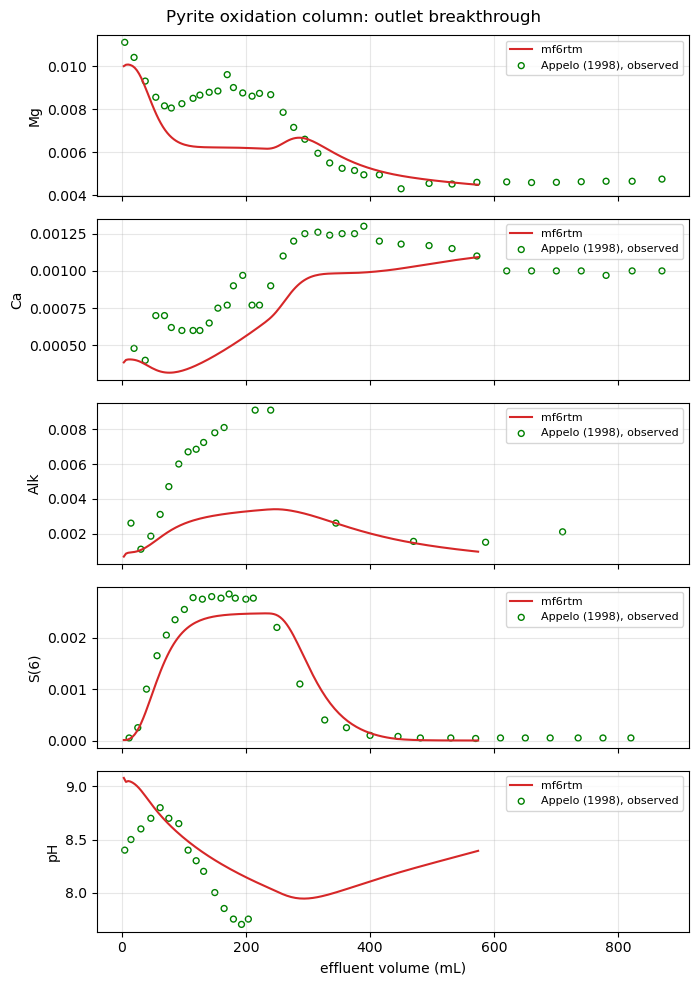

In [10]:
sout = pd.read_csv(os.path.join(model.wd, "sout.csv"))
qml = q * 1.0e6  # m3/d -> mL/d, so time (d) * qml = effluent volume (mL)
outlet = sout[sout["col"] == sout["col"].max()].copy()
outlet["vol"] = outlet["time_d"] * qml

# Measured effluent data (real experiment, not a model benchmark).
obs = pd.read_csv(os.path.join(DATA, "tut02_obs.txt"), sep="\t", skipinitialspace=True)
obs.replace(-9999, np.nan, inplace=True)
obs.dropna(axis=0, how="all", inplace=True)
obs.columns = ["vol", "Mg", "Ca", "Alk", "Cl", "S(6)", "pH"]
obs.set_index("vol", inplace=True)
obs = obs.iloc[3:, :]

plot_vars = [v for v in ["Mg", "Ca", "Alk", "S(6)", "pH"] if v in outlet.columns]

fig, axs = plt.subplots(len(plot_vars), 1, figsize=(7, 2.0 * len(plot_vars)),
                        sharex=True)
for ax, var in zip(np.atleast_1d(axs), plot_vars):
    ax.plot(outlet["vol"], outlet[var], color="tab:red", zorder=10, label="mf6rtm")
    if var in obs.columns:
        ax.scatter(obs.index, obs[var], s=18, facecolors="none",
                   edgecolors="green", label="Appelo (1998), observed")
    ax.set_ylabel(var)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
np.atleast_1d(axs)[-1].set_xlabel("effluent volume (mL)")
fig.suptitle("Pyrite oxidation column: outlet breakthrough")
fig.tight_layout()